In [ ]:
# Clone the repository just for the dataset script
!git clone https://github.com/karpathy/nanoGPT.git
%cd nanoGPT

# Prepare the Tiny Shakespeare dataset
!python data/shakespeare_char/prepare.py

Cloning into 'nanoGPT'...
remote: Enumerating objects: 689, done.
remote: Total 689 (delta 0), reused 0 (delta 0), pack-reused 689 (from 1)
Receiving objects: 100% (689/689), 975.24 KiB | 40.63 MiB/s, done.
Resolving deltas: 100% (382/382), done.
/content/nanoGPT
length of dataset in characters: 1,115,394
all the unique characters: 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
vocab size: 65
train has 1,003,854 tokens
val has 111,540 tokens


In [ ]:
import os
import pickle
import numpy as np
import torch
import torch.nn as nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# Hyperparams from prior step
batch_size = 64
block_size = 256
n_embd = 384
n_hidden = 384
n_layers = 2
learning_rate = 1e-3
device = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"Using device: {device}")

# Load data
data_dir = 'data/shakespeare_char'
train_data = np.memmap(os.path.join(data_dir, 'train.bin'), dtype=np.uint16, mode='r')
val_data = np.memmap(os.path.join(data_dir, 'val.bin'), dtype=np.uint16, mode='r')

with open(os.path.join(data_dir, 'meta.pkl'), 'rb') as f:
    meta = pickle.load(f)

vocab_size = meta['vocab_size']
stoi = meta['stoi']
itos = meta['itos']
encode = lambda s: [stoi.get(c, 0) for c in s]
decode = lambda l: ''.join([itos[i] for i in l])

# Dataset
class ShakespeareDataset(Dataset):
    def __init__(self, data, block_size):
        self.data = data
        self.block_size = block_size
        # Calculate exact number of non overlapping blocks
        self.num_blocks = (len(data) - 1) // block_size

    def __len__(self):
        return self.num_blocks

    def __getitem__(self, idx):
        # Grab a chunk of text
        start_idx = idx * self.block_size
        x = torch.tensor(self.data[start_idx : start_idx + self.block_size], dtype=torch.long)
        y = torch.tensor(self.data[start_idx + 1 : start_idx + 1 + self.block_size], dtype=torch.long)
        return x, y

# Initialize Dataloaders
train_dataset = ShakespeareDataset(train_data, block_size)
val_dataset = ShakespeareDataset(val_data, block_size)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"Steps per epoch (Batches): {len(train_loader)}")

Using device: cuda
Steps per epoch (Batches): 62


In [ ]:
class CharLSTM(nn.Module):
    def __init__(self, vocab_size, n_embd, n_hidden, n_layers):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, n_embd)
        self.lstm = nn.LSTM(n_embd, n_hidden, n_layers, batch_first=True)
        self.fc = nn.Linear(n_hidden, vocab_size)

    def forward(self, x):
        emb = self.embedding(x)
        out, _ = self.lstm(emb)
        return self.fc(out)

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, block_size, temperature=1.0):
        self.eval()
        for _ in range(max_new_tokens):
            # Crop context to block_size to avoid indexing errors
            idx_cond = idx if idx.size(1) <= block_size else idx[:, -block_size:]
            logits = self(idx_cond)
            # Focus only on the last predicted character
            logits = logits[:, -1, :] / temperature
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        self.train()
        return idx

def train_epoch(dataloader, model, loss_fn, optimizer, device):
    model.train()
    total_loss = 0
    for X, y in dataloader:
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(X)

        # Reshape for Cross Entropy
        loss = loss_fn(logits.view(-1, logits.size(-1)), y.view(-1))
        loss.backward()

        # Gradient clipping to prevent exploding gradients in RNNs
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

def test_epoch(dataloader, model, loss_fn, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            loss = loss_fn(logits.view(-1, logits.size(-1)), y.view(-1))
            total_loss += loss.item()

    return total_loss / len(dataloader)

In [ ]:
lstm_model = CharLSTM(vocab_size, n_embd, n_hidden, n_layers).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(lstm_model.parameters(), lr=learning_rate)

epochs = 500
target_epochs = {5, 50, 500}

train_losses = []
val_losses = []

print("--- Starting Character LSTM Training ---")

for t in range(1, epochs + 1):
    t_loss = train_epoch(train_loader, lstm_model, loss_fn, optimizer, device)
    v_loss = test_epoch(val_loader, lstm_model, loss_fn, device)

    train_losses.append(t_loss)
    val_losses.append(v_loss)

    # Keep console output clean: print every 10 epochs or on a target epoch
    if t % 10 == 0 or t in target_epochs or t == 1:
        print(f"Epoch {t:3d}/{epochs} | Train Loss: {t_loss:.4f} | Val Loss: {v_loss:.4f}")

    # Deliverable: Generate sample at specific milestones
    if t in target_epochs:
        print(f"\n========== TASK B: {t} EPOCH SAMPLE ==========")
        start_ids = encode("ROMEO:\n")
        x_gen = torch.tensor(start_ids, dtype=torch.long, device=device).unsqueeze(0)
        y_gen = lstm_model.generate(x_gen, max_new_tokens=500, block_size=block_size, temperature=1.0)
        print(f"--- SAMPLE ---\n{decode(y_gen[0].tolist())}\n--------------\n")

print("Training Complete!")

--- Starting Character LSTM Training ---
Epoch   1/500 | Train Loss: 2.7627 | Val Loss: 2.2012
Epoch   5/500 | Train Loss: 1.5362 | Val Loss: 1.6597

========== TASK B: 5 EPOCH SAMPLE ==========
--- SAMPLE ---
ROMEO:
Thou wilt let suful, allow the man, day the wife,
And the wrappire of a Duijed that's you
Consed thou, he one hent to you.

LUCIO:
So barts, or a fing of thy trawn:
Shall sxon'd the queeting matience, midst thou found,
Leat-not the long of cliogn as glooked and that flowers
To the ingroone, sand; 'tis execution?

To RICAPULE:
Their, as to this so sancume, done as so more,
Hears and but have so fail we doth to woed, that
thy cans that tow,--were me, to'ster, then, at I was even,
And madle breen y
--------------

Epoch  10/500 | Train Loss: 1.3508 | Val Loss: 1.5286
Epoch  20/500 | Train Loss: 1.2068 | Val Loss: 1.4848
Epoch  30/500 | Train Loss: 1.1060 | Val Loss: 1.5032
Epoch  40/500 | Train Loss: 1.0064 | Val Loss: 1.5710
Epoch  50/500 | Train Loss: 0.8961 | Val Loss: 1.6

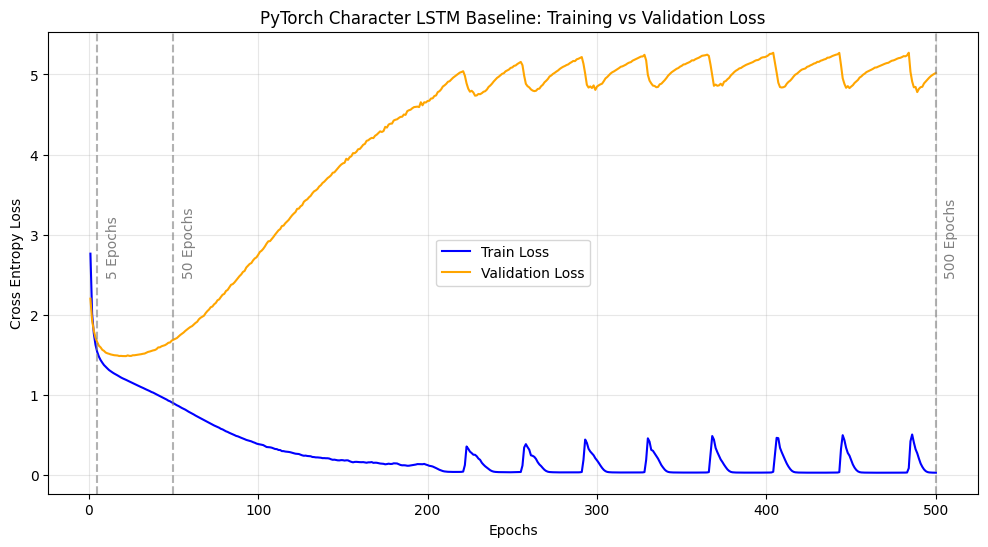

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Train Loss', color='blue')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss', color='orange')

# Add milestone markers
for target in target_epochs:
    plt.axvline(x=target, color='gray', linestyle='--', alpha=0.6)
    plt.text(target + 5, max(train_losses)*0.9, f'{target} Epochs', rotation=90, color='gray')

plt.title("PyTorch Character LSTM Baseline: Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Cross Entropy Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### PART C COMPARISON

Generally, by the plots, both models got to about the same minimal cross entropy loss. Both models started overfitting around the 20 epoch range and continued to degrade from here. Notably, the LSTM model overfit much faster, evident by the faster increase in loss. Strangely the LSTM model also fell into cyclical "spikes" in loss, likely due to pertubations in steps taken by the optimizer. Those spikes may very well correspond to gradient clipping to avoid exploding gradients (remember we introduced this in the training function).

At epoch 5, LSTM wins on validation loss (1.689 vs 1.9849). LSTM clearly is better at forming words, while GPT was further making mistakes on common words like names (ROMEONES:). GPT remains fairly garbled.

At epoch 50, GPT wins in validation loss (1.5189 vs 1.689). Both models now form coherent words. GPT makes much less mistakes on spelling out words and is now forming logical phrases. LSTM makes more mistakes on individual word spellings and is logically incoherent in sentence flow. GPT has picked up on grammar and general sentence structures "we fear thy blood," "And here for Corioli gates and crowns for them."

At epoch 500, GPT wins in validation loss (3.2611 vs 5.0184). Both models spell words well, GPT does better. GPT does not spell a single word wrong. LSTM still does not make much sense on a sentence basis, but GPT does. "O Romeo, Romeo, Romeo, brave Mercutio's dead! That gallant spirit hath aspired (end of 500 words)."

I didn't notice any clear repetition loops on either model. Generally, GPT is more coherent and formatted, except for the 5 epoch sample. GPT outperformed on character and word structures, being able to form logical sentences, while LSTM struggled in both categories.

The biggest difference between models, as alluded to above, is that LSTM consistently struggled with spelling (character structure) while GPT was able to almost always spell out words. GPT uses self attention, allowing it to look directly back at all prior 256 letters in the block simultaneously. In LSTMs, while that context thread does go back 256 lines, it does so sequentially, with a step in gradients across each character in the sequence. Influence, and gradients, vanish the farther we go back, as it should in sequential data. We don't have 256 feature vectors for each state to look at, we have one which chains back all the way, thus influence wanes over time. GPT doesn't do this, so it holds onto those nuances over the length of words. It also directly explains how GPT forms coherent sentences while LSTM does not.